# Inference Notebook

This notebook loads `./models/best_model.pt`, runs inference for a single image or every image inside a folder, and visualizes the detections.

Update `INPUT_PATH` in the last cell to either an image file or a directory.

In [4]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import BackboneWithFPN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from checkpoint_loader import load_detection_checkpoint

PROJECT_ROOT = Path('.').resolve()
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_model_strawberry.pt'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
IMAGE_MIN_SIZE = 640
IMAGE_MAX_SIZE = 640
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
COLORS = {
    1: (255, 80, 80),
    2: (80, 180, 80),
    3: (80, 120, 255),
}


def build_resnet50_fasterrcnn(num_classes: int) -> FasterRCNN:
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None,
        min_size=IMAGE_MIN_SIZE,
        max_size=IMAGE_MAX_SIZE,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def build_convnext_fasterrcnn(num_classes: int, variant: str = 'small', last_return_layer: str = '7') -> FasterRCNN:
    from torchvision.models import convnext_small, convnext_tiny

    builders = {
        'tiny': lambda: convnext_tiny(weights=None).features,
        'small': lambda: convnext_small(weights=None).features,
    }
    if variant not in builders:
        raise ValueError(f'Unsupported convnext variant: {variant}')

    backbone_body = builders[variant]()
    backbone = BackboneWithFPN(
        backbone=backbone_body,
        return_layers={'3': '0', '5': '1', last_return_layer: '2'},
        in_channels_list=[192, 384, 768],
        out_channels=256,
    )
    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,), (256,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 4,
    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0', '1', '2', 'pool'],
        output_size=7,
        sampling_ratio=2,
    )
    return FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=IMAGE_MIN_SIZE,
        max_size=IMAGE_MAX_SIZE,
    )


def detect_last_return_layer(state_dict: dict) -> str:
    return '7' if any(key.startswith('backbone.body.7') for key in state_dict) else '6'


def build_model(backbone_name: str, num_classes: int, state_dict: dict | None = None) -> FasterRCNN:
    if backbone_name == 'resnet50':
        return build_resnet50_fasterrcnn(num_classes)
    if backbone_name in ('convnext_tiny', 'convnext_small'):
        last_return_layer = detect_last_return_layer(state_dict or {})
        return build_convnext_fasterrcnn(
            num_classes,
            variant=backbone_name.split('_')[1],
            last_return_layer=last_return_layer,
        )
    raise ValueError(f'Unsupported backbone: {backbone_name}')


def load_model(model_path: Path, device: torch.device):
    if not model_path.exists():
        raise FileNotFoundError(f'Model file not found: {model_path}')

    loaded = load_detection_checkpoint(
        model_path,
        device=device,
        image_min_size=IMAGE_MIN_SIZE,
        image_max_size=IMAGE_MAX_SIZE,
    )
    return (
        loaded['model'],
        loaded['checkpoint'],
        loaded['backbone_name'],
        loaded['label_to_name'],
        loaded['fpn_return_layers'],
    )


def find_images(path_like) -> list[Path]:
    path = Path(path_like)
    if path.is_file() and path.suffix.lower() in IMG_EXTENSIONS:
        return [path]
    if path.is_dir():
        return sorted([p for p in path.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS])
    raise FileNotFoundError(f'Image file or directory not found: {path}')


@torch.inference_mode()
def predict_one(model, image_path: Path, score_threshold: float = 0.25):
    image = Image.open(image_path).convert('RGB')
    tensor = TF.to_tensor(image).to(DEVICE)
    output = model([tensor])[0]

    scores = output['scores'].detach().cpu()
    keep = scores >= score_threshold
    boxes = output['boxes'].detach().cpu()[keep]
    labels = output['labels'].detach().cpu()[keep]
    scores = scores[keep]
    return image, boxes, labels, scores


def draw_predictions(image, boxes, labels, scores, label_to_name):
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)

    for box, label, score in zip(boxes.tolist(), labels.tolist(), scores.tolist()):
        color = COLORS.get(int(label), (255, 200, 0))
        text = f"{label_to_name.get(int(label), f'cls_{int(label)}')}: {score:.2f}"
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text_bg = [x1, max(0, y1 - 18), x1 + len(text) * 7 + 6, y1]
        draw.rectangle(text_bg, fill=color)
        draw.text((x1 + 3, max(0, y1 - 16)), text, fill=(255, 255, 255))
    return canvas


def visualize_predictions(results, cols: int = 2, figsize_scale: int = 6):
    if not results:
        print('No images to display.')
        return

    rows = math.ceil(len(results) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_scale, rows * figsize_scale))
    axes = np.array(axes, dtype=object).reshape(rows, cols)

    for idx, result in enumerate(results):
        row, col = divmod(idx, cols)
        axes[row, col].imshow(result['canvas'])
        axes[row, col].set_title(
            f"{result['path'].name}\n{len(result['boxes'])} detection(s)",
            fontsize=10,
        )
        axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row, col = divmod(idx, cols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


def run_inference(model, image_paths, label_to_name, score_threshold=0.25, max_display=8, save_dir=None):
    selected_paths = image_paths[:max_display]
    results = []

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    for index, image_path in enumerate(selected_paths, start=1):
        image, boxes, labels, scores = predict_one(model, image_path, score_threshold=score_threshold)
        canvas = draw_predictions(image, boxes, labels, scores, label_to_name)
        results.append({
            'path': image_path,
            'boxes': boxes,
            'labels': labels,
            'scores': scores,
            'canvas': canvas,
        })
        print(f'[{index}/{len(selected_paths)}] {image_path} -> {len(boxes)} detection(s)')

        if save_dir is not None:
            output_path = save_dir / f'{image_path.stem}_pred{image_path.suffix}'
            canvas.save(output_path)

    if len(image_paths) > max_display:
        print(f'Only the first {max_display} image(s) were processed for display.')

    return results


model, checkpoint, backbone_name, label_to_name, fpn_return_layers = load_model(MODEL_PATH, DEVICE)
print('Loaded model   :', MODEL_PATH)
print('Device         :', DEVICE)
print('Backbone       :', backbone_name)
print('FPN layers     :', fpn_return_layers)
print('Num classes    :', checkpoint.get('num_classes'))
print('Class mapping  :', label_to_name)
print('Best val loss  :', checkpoint.get('best_val_loss'))
print('Saved epochs   :', checkpoint.get('epochs'))


Loaded model   : C:\potenup3\pj03-SFAX\models\best_model_strawberry.pt
Device         : cuda:0
Backbone       : convnext_small
FPN layers     : {'2': '0', '4': '1', '6': '2'}
Num classes    : 4
Class mapping  : {1: 'normal', 2: 'gray_mold', 3: 'powdery_mildew'}
Best val loss  : 0.07115601291472733
Saved epochs   : 5


Found image files: 3
[1/3] C:\potenup3\pj03-SFAX\images\img0.jpg -> 1 detection(s)
[2/3] C:\potenup3\pj03-SFAX\images\img1.jpg -> 1 detection(s)
[3/3] C:\potenup3\pj03-SFAX\images\img2.jpg -> 1 detection(s)


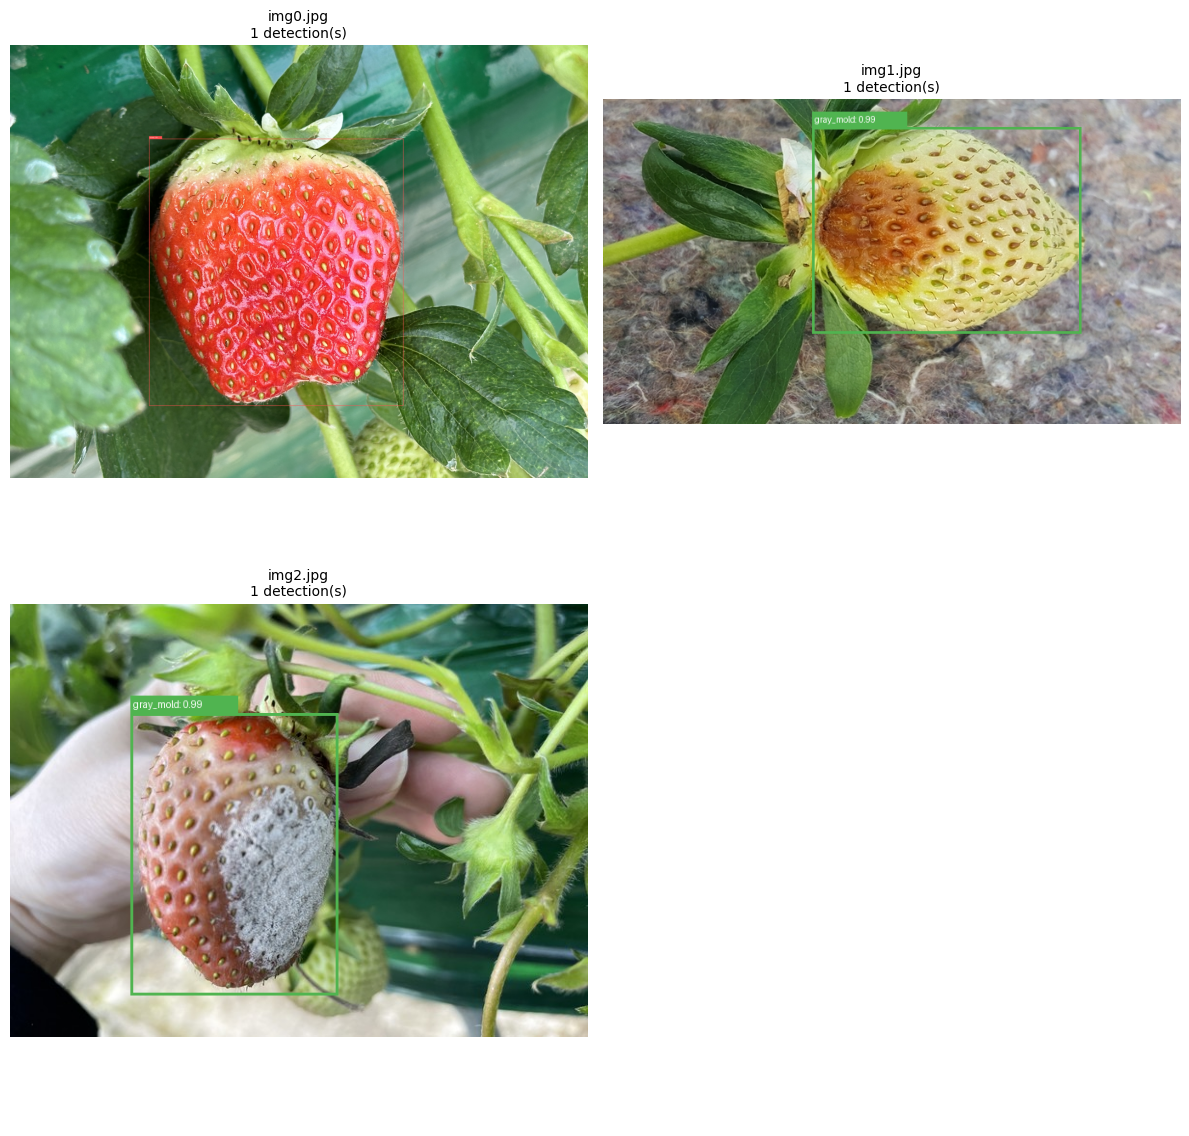

In [5]:
INPUT_PATH = PROJECT_ROOT / 'images'
# INPUT_PATH = PROJECT_ROOT / 'images' / 'sample.jpg'

SCORE_THRESHOLD = 0.25
MAX_DISPLAY = 8
COLS = 2
SAVE_DIR = None
# SAVE_DIR = PROJECT_ROOT / 'runs' / 'infer_vis'

image_paths = find_images(INPUT_PATH)
print('Found image files:', len(image_paths))

results = run_inference(
    model=model,
    image_paths=image_paths,
    label_to_name=label_to_name,
    score_threshold=SCORE_THRESHOLD,
    max_display=MAX_DISPLAY,
    save_dir=SAVE_DIR,
)

visualize_predictions(results, cols=COLS)
